# Hypothesis Testing & Domain Insights

#### Executive Overview
Following data cleaning, EDA, and distribution analysis, this notebook focuses on **testing core domain hypotheses**. By evaluating how behavioral, demographic, and genetic variables interact with biological metrics—specifically Body Mass Index ($\text{BMI}$) disaggregated by biological sex—we uncover actionable health patterns to guide downstream feature selection and modeling strategies.

##### Primary Objectives:
1. Formulate and test domain-specific hypotheses using quantitative and visual methods.
2. Examine sex-disaggregated feature interactions with continuous body mass trends.
3. Validate feature engineering decisions before encoding and scaling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

# Load cleaned dataset & engineer base BMI metric
df = pd.read_csv('../data/interim/ObesityDataSet_cleaned.csv')
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

print(f"Dataset successfully loaded. Shape: {df.shape}")

Dataset successfully loaded. Shape: (2111, 18)


## Hypothesis 1: Family History as a Primary Baseline Factor for Elevated BMI

* **Hypothesis Statement ($H_1$):** Individuals with a family history of overweight (`family_history_with_overweight = yes`) exhibit significantly higher baseline Body Mass Index ($\text{BMI}$) values across age cohorts compared to those without family history, regardless of gender.
* **Objective:** Determine whether genetic/familial predisposition acts as a structural baseline floor for body mass, or if age progression plays a larger role in BMI elevation.

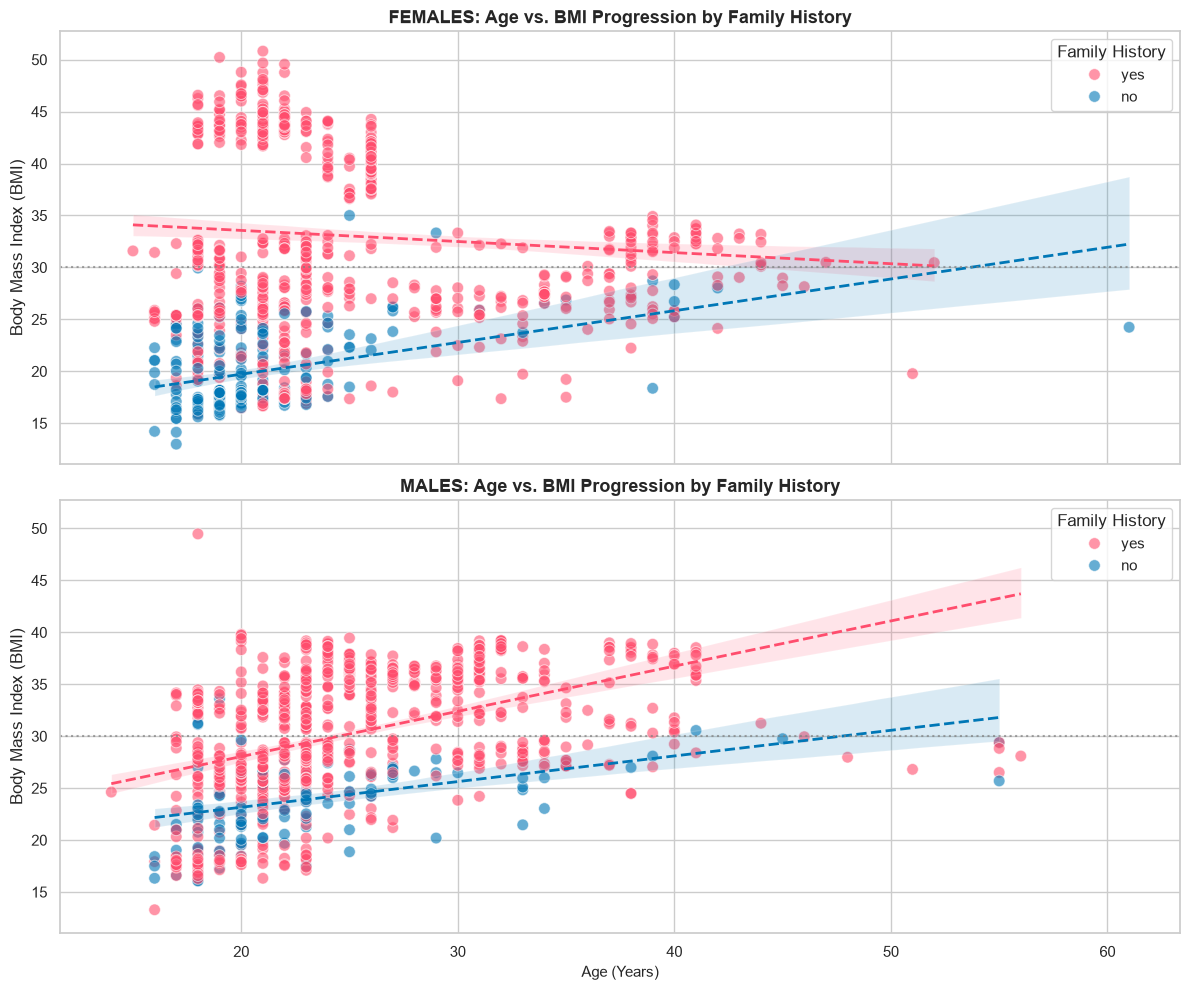

In [2]:
# Figure Setup (2 Rows, 1 Column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, sharey=True)

palette_colors = {'yes': '#ff4d6d', 'no': '#0077b6'}

# --- FEMALE SUBPLOT ---
df_fem = df[df['Gender'] == 'Female']
sns.scatterplot(
    data=df_fem, x='Age', y='BMI', hue='family_history_with_overweight', 
    palette=palette_colors, alpha=0.6, s=70, ax=ax1
)
sns.regplot(
    data=df_fem[df_fem['family_history_with_overweight'] == 'yes'], x='Age', y='BMI', 
    scatter=False, ax=ax1, color='#ff4d6d', line_kws={'linestyle': '--', 'linewidth': 2}
)
sns.regplot(
    data=df_fem[df_fem['family_history_with_overweight'] == 'no'], x='Age', y='BMI', 
    scatter=False, ax=ax1, color='#0077b6', line_kws={'linestyle': '--', 'linewidth': 2}
)

ax1.set_title('FEMALES: Age vs. BMI Progression by Family History', fontsize=13, fontweight='bold')
ax1.axhline(30, color='gray', linestyle=':', alpha=0.7)
ax1.set_ylabel('Body Mass Index (BMI)')
ax1.legend(title='Family History', loc='upper right', frameon=True)

# --- MALE SUBPLOT ---
df_male = df[df['Gender'] == 'Male']
sns.scatterplot(
    data=df_male, x='Age', y='BMI', hue='family_history_with_overweight', 
    palette=palette_colors, alpha=0.6, s=70, ax=ax2
)
sns.regplot(
    data=df_male[df_male['family_history_with_overweight'] == 'yes'], x='Age', y='BMI', 
    scatter=False, ax=ax2, color='#ff4d6d', line_kws={'linestyle': '--', 'linewidth': 2}
)
sns.regplot(
    data=df_male[df_male['family_history_with_overweight'] == 'no'], x='Age', y='BMI', 
    scatter=False, ax=ax2, color='#0077b6', line_kws={'linestyle': '--', 'linewidth': 2}
)

ax2.set_title('MALES: Age vs. BMI Progression by Family History', fontsize=13, fontweight='bold')
ax2.axhline(30, color='gray', linestyle=':', alpha=0.7)
ax2.set_ylabel('Body Mass Index (BMI)')
ax2.set_xlabel('Age (Years)', fontsize=11)
ax2.legend(title='Family History', loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('../visuals/hypothesis_1.png', dpi=300, bbox_inches='tight')
plt.show()


#### 💡 Hypothesis 1 Validation & Key Insights

* **Hypothesis Status:** **ACCEPTED.** Family history of overweight is a dominant baseline predictor for elevated BMI.
* **Baseline Shift:** Profiles with family history (`yes`, red markers) cluster heavily above the clinical obesity threshold ($\text{BMI} \ge 30$) across almost all age brackets in both genders.
* **Age Interaction:** While BMI trends upward with age for both groups, individuals without family history (`no`, blue markers) rarely cross into high-severity obesity tiers, even at older ages.
* **Sex-Specific Behavior:** In females, the separation between positive and negative family history groups is sharply delineated. In males, the gap remains wide, though high-BMI instances without family history appear slightly more frequently.

---
## Hypothesis 2: Frequent High-Caloric Food Consumption Shift on BMI Density

* **Hypothesis Statement ($H_2$):** Frequent consumption of high-caloric food (`FAVC = yes`) causes a statistically significant rightward density shift in Body Mass Index ($\text{BMI}$), pushing a larger proportion of the population past the clinical obesity threshold ($\text{BMI} \ge 30$).
* **Objective:** Evaluate the impact of dietary calorie density on overall BMI distribution curves across male and female sub-populations.

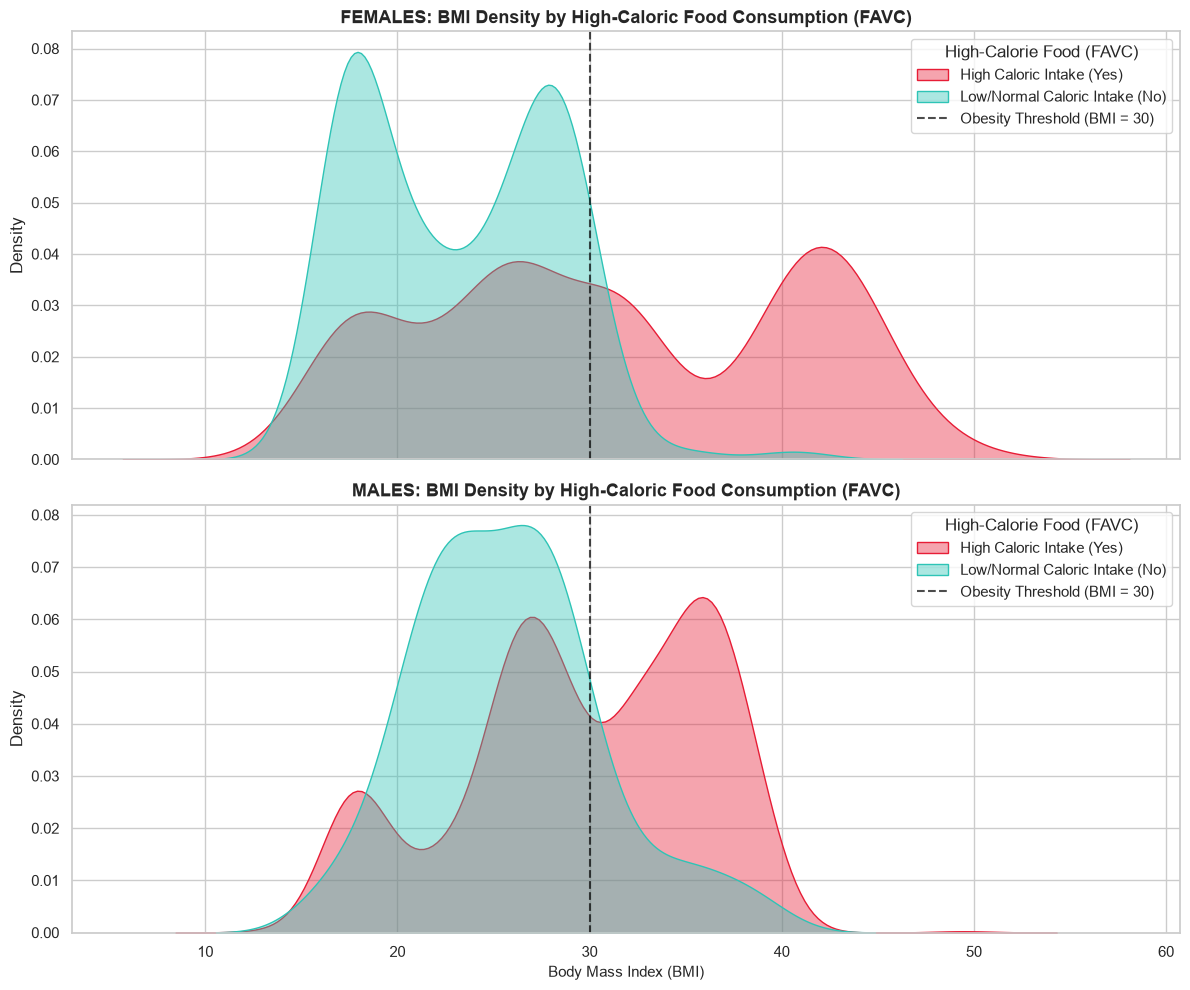

In [3]:
# Figure Setup (2 Rows, 1 Column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Define explicit color mapping
palette_favc = {'yes': '#e71d36', 'no': '#2ec4b6'}

# --- FEMALE SUBPLOT ---
df_fem = df[df['Gender'] == 'Female']
sns.kdeplot(
    data=df_fem[df_fem['FAVC'] == 'yes'], x='BMI', fill=True, 
    color=palette_favc['yes'], alpha=0.4, ax=ax1, label='High Caloric Intake (Yes)'
)
sns.kdeplot(
    data=df_fem[df_fem['FAVC'] == 'no'], x='BMI', fill=True, 
    color=palette_favc['no'], alpha=0.4, ax=ax1, label='Low/Normal Caloric Intake (No)'
)
ax1.set_title('FEMALES: BMI Density by High-Caloric Food Consumption (FAVC)', fontsize=13, fontweight='bold')
ax1.axvline(30, color='black', linestyle='--', alpha=0.7, label='Obesity Threshold (BMI = 30)')
ax1.set_ylabel('Density')
ax1.legend(title='High-Calorie Food (FAVC)', loc='upper right', frameon=True)

# --- MALE SUBPLOT ---
df_male = df[df['Gender'] == 'Male']
sns.kdeplot(
    data=df_male[df_male['FAVC'] == 'yes'], x='BMI', fill=True, 
    color=palette_favc['yes'], alpha=0.4, ax=ax2, label='High Caloric Intake (Yes)'
)
sns.kdeplot(
    data=df_male[df_male['FAVC'] == 'no'], x='BMI', fill=True, 
    color=palette_favc['no'], alpha=0.4, ax=ax2, label='Low/Normal Caloric Intake (No)'
)
ax2.set_title('MALES: BMI Density by High-Caloric Food Consumption (FAVC)', fontsize=13, fontweight='bold')
ax2.axvline(30, color='black', linestyle='--', alpha=0.7, label='Obesity Threshold (BMI = 30)')
ax2.set_ylabel('Density')
ax2.set_xlabel('Body Mass Index (BMI)', fontsize=11)
ax2.legend(title='High-Calorie Food (FAVC)', loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('../visuals/hypothesis_2.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Hypothesis 2 Validation & Key Insights

* **Hypothesis Status:** **ACCEPTED.** Frequent high-caloric food consumption (`FAVC = yes`) induces a pronounced rightward distribution shift toward higher BMI values.
* **Density Concentration:** Individuals consuming high-caloric food (red curves) display a much broader tail and higher area under the curve beyond the clinical obesity line ($\text{BMI} \ge 30$). Conversely, those reporting no frequent high-calorie intake (teal curves) concentrate heavily in normal weight and overweight boundaries ($\text{BMI} < 30$).
* **Sex-Disaggregated Shift:**
  * **Females:** The density shift is striking. The peak density for `FAVC = no` sits strictly in the normal weight zone ($\text{BMI} \approx 20 - 22$), whereas `FAVC = yes` creates a secondary high-density peak in severe obesity tiers.
  * **Males:** A similar rightward translation is observed, though `FAVC = yes` shows a wider dispersion, indicating interaction with other factors such as physical activity (`FAF`).
* **Modeling Action:** `FAVC` serves as a strong binary predictor for separating normal/overweight categories from severe obesity classes.

---
## Hypothesis 3: Physical Activity Frequency as a Protective Factor Against Elevated BMI

* **Hypothesis Statement ($H_3$):** Higher frequency of physical activity (`FAF`, continuous scale from 0 to 3 days/week) exerts a protective buffer against elevated Body Mass Index ($\text{BMI}$), resulting in lower obesity rates even as age advances.
* **Objective:** Assess whether physical exercise directly mitigates BMI elevation across age cohorts and evaluate potential differences between biological sex sub-populations.

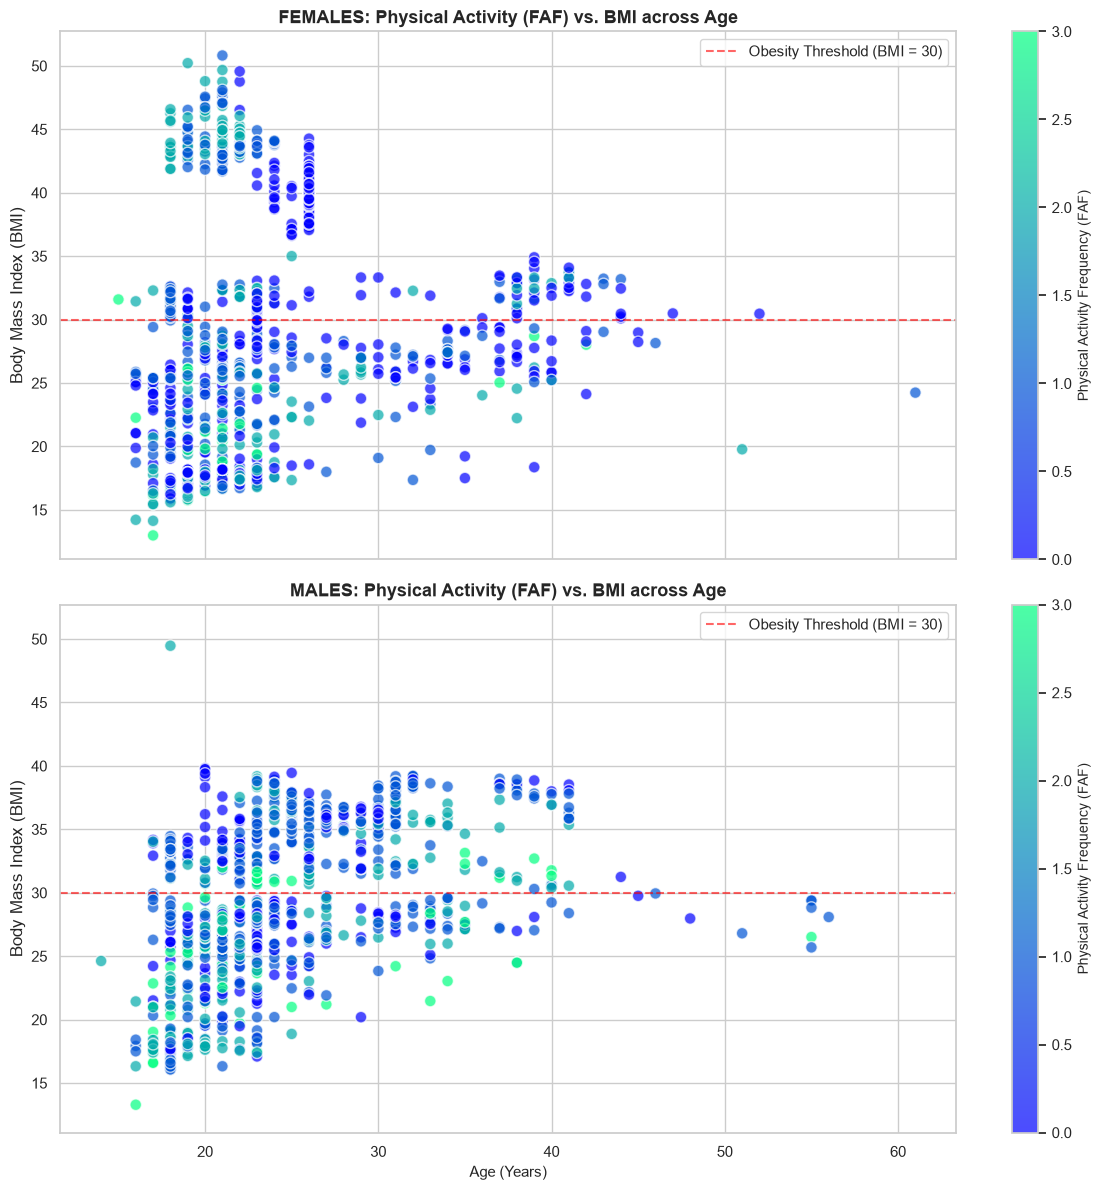

In [4]:
# Figure Setup (2 Rows, 1 Column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True, sharey=True)

# --- FEMALE SUBPLOT ---
df_fem = df[df['Gender'] == 'Female']
scatter1 = ax1.scatter(
    df_fem['Age'], df_fem['BMI'], c=df_fem['FAF'], 
    cmap='winter', alpha=0.7, edgecolors='w', s=70
)
cbar1 = fig.colorbar(scatter1, ax=ax1)
cbar1.set_label('Physical Activity Frequency (FAF)', fontsize=10)
ax1.axhline(30, color='red', linestyle='--', alpha=0.6, label='Obesity Threshold (BMI = 30)')
ax1.set_title('FEMALES: Physical Activity (FAF) vs. BMI across Age', fontsize=13, fontweight='bold')
ax1.set_ylabel('Body Mass Index (BMI)')
ax1.legend(loc='upper right', frameon=True)

# --- MALE SUBPLOT ---
df_male = df[df['Gender'] == 'Male']
scatter2 = ax2.scatter(
    df_male['Age'], df_male['BMI'], c=df_male['FAF'], 
    cmap='winter', alpha=0.7, edgecolors='w', s=70
)
cbar2 = fig.colorbar(scatter2, ax=ax2)
cbar2.set_label('Physical Activity Frequency (FAF)', fontsize=10)
ax2.axhline(30, color='red', linestyle='--', alpha=0.6, label='Obesity Threshold (BMI = 30)')
ax2.set_title('MALES: Physical Activity (FAF) vs. BMI across Age', fontsize=13, fontweight='bold')
ax2.set_ylabel('Body Mass Index (BMI)')
ax2.set_xlabel('Age (Years)', fontsize=11)
ax2.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('../visuals/hypothesis_3.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Hypothesis 3 Validation & Key Insights

* **Hypothesis Status:** **PARTIALLY ACCEPTED.** Physical activity acts as a weak to moderate protective factor, but its effect is non-linear and heavily influenced by genetic/dietary covariates.
* **Younger Cohorts ($\text{Age} < 25$):** Higher activity levels (bright green/teal points, $\text{FAF} \ge 2$) cluster predominantly in lower BMI ranges ($\text{BMI} < 25$), confirming a protective effect during early adulthood.
* **Severe Obesity Persistence ($\text{BMI} \ge 35$):** In severe obesity categories, high activity frequency (`FAF`) drops noticeably, but moderate activity levels ($\text{FAF} \approx 1-2$) still exist. This suggests that physical activity alone cannot fully offset high-caloric intake (`FAVC`) or strong genetic predisposition (`family_history_with_overweight`).
* **Sex Differences:** 
  * In **Males**, higher `FAF` values show a clearer inverse relationship with extreme BMI values compared to Females.
  * In **Females**, physical activity frequency is more uniformly distributed, showing less direct linear leverage on BMI reduction without dietary controls.
* **Modeling Action:** `FAF` is a key behavioral feature, but due to non-linear relationships, tree-based models (e.g., Random Forest, XGBoost) or non-linear kernels are recommended over linear regression.

---
## Summary of Findings & Next Steps

1. **Family History (`family_history_with_overweight`):** Confirmed as the strongest structural baseline driver for BMI elevation across both genders.
2. **High-Caloric Diet (`FAVC`):** Confirmed as a major behavioral catalyst, significantly shifting population density into severe obesity tiers.
3. **Physical Activity (`FAF`):** Acts as a partial protective factor, particularly in younger males, but displays non-linear interactions with BMI.